In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from typing import Callable, Optional, Tuple
from tqdm.notebook import tqdm

from IPython.display import clear_output

from torchvision.datasets.mnist import MNIST
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

# MNIST calculator

In this tutorial you are to implement a model that calculates the mod 10 sum of two digits in MNIST.

### Task 1. Prepare the data for the training.

Implement the `Digits` dataset class that wraps the MNIST class and augments it with the mod 10 sum of two digits.

In [5]:
class Digits(Dataset):
    def __init__(self, root: str, train: bool = True, download: bool = True, transforms: Optional[Callable] = None):
        super(Digits, self).__init__()
        
        # Construct your MNIST instance here
        self.mnist = MNIST(root=root, train=train, download=download, transform=transforms)
        
    def __getitem__(self, idx: int) -> Tuple[torch.FloatTensor, torch.FloatTensor, int]:
        """
        Returns the datapoint at index = idx.
        You need to implement this method in such a way
        that the ith element of the Digits class
        is a pair of subsequent MNIST dataset samples.
        That is if MNIST is [a, b, c, d], then Digits
        are [[a, b], [c, d]] and the label is mod 10
        sum of the MNIST labels.
        
        :param idx: Index of the datapoint.
        :return: 2 image tensors, their mod 10 sum.
        """
        
        ##### Write your code here #####
        first, first_label = self.mnist[2 * idx]
        second, second_label = self.mnist[2 * idx + 1]

        return first, second, (first_label + second_label) % 10
        ################################
    
    def __len__(self) -> int:
        """
        Returns the length of the dataset. Equals half the length of the MNIST dataset.
        
        :return: The total number of datapoints in the dataset.
        """
        
        ##### Write your code here #####
        return len(self.mnist) // 2
        ################################

Construct the train and the test splits of the dataset. Leave 90% of the training set for training and the remaining 10% for the validation.

In [22]:
##### Write your code here #####

transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])

train_set = Digits(root="data", train=True, download=True, transforms=transforms)
test_set = Digits(root="data", train=False, download=True, transforms=transforms)

################################

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 320kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.96MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.31MB/s]


### Task 2. Inspect data

Visualize some datapoints.

In [23]:
##### Write your code here #####

first, second, label = train_set[0]

################################

In [24]:
first.shape

torch.Size([1, 28, 28])

In [26]:
first.max()
print(len(train_set))


30000


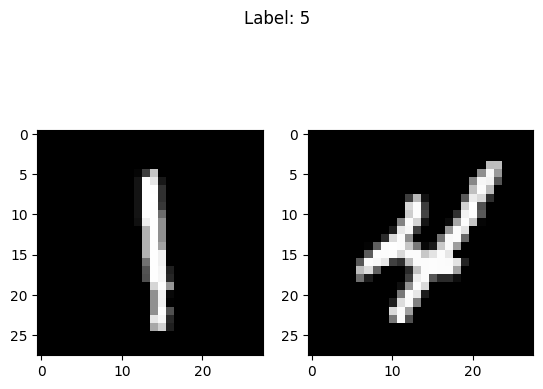

In [27]:
first, second, label = train_set[4]

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(first[0], cmap="gray")

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(second[0], cmap="gray")

plt.suptitle(f"Label: {label}")

plt.show()

### Task 3. Train an MLP (multi-layer perceptron).

Design and train an MLP. Consider using different
activation functions, normalization layers and dropout. Plot all the training curves.

In [28]:
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0
    # Iterate mini batches over training dataset
    for first, second, labels in tqdm(train_dataloader):
        # move tensors to current device
        first = first.to(device)
        second = second.to(device)
        images = torch.cat([first, second], dim=1)
        labels = labels.to(device)
        # Run predictions
        output = model(images)
        
        # Set gradients to zero
        # https://pytorch.org/docs/stable/optim.html
        # https://discuss.pytorch.org/t/why-do-we-need-to-set-the-gradients-manually-to-zero-in-pytorch/4903/20
        optimizer.zero_grad()
        
        # Compute loss
        loss = loss_fn(output, labels)
        
        # Backpropagate (compute gradients)
        loss.backward()
        
        # Make an optimization step (update parameters)
        optimizer.step()
        
        # Log metrics
        losses.append(loss.item())
        predicted_labels = output.argmax(dim=1)
        correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = 100.0 * correct_predictions / len(train_dataloader.dataset)
    # Return loss values for each iteration and accuracy
    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy


def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for first, second, labels in dataloader:
            
            #move tensors to current device
            first = first.to(device)
            second = second.to(device)
            images = torch.cat([first, second], dim=1)
            labels = labels.to(device)
            # Run predictions
            output = model(images)
            
            
            # Compute loss
            loss = loss_fn(output, labels)
            
            
            predicted_labels = output.argmax(dim=1)
            correct_predictions += (predicted_labels == labels).sum().item()
            losses.append(loss.item())
    mean_loss = np.array(losses).mean()
    accuracy = 100.0 * correct_predictions / len(dataloader.dataset)
    # Return mean loss and accuracy
    return mean_loss, accuracy


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(n_epochs):
        # set model to train mode
        model.train()
        # train the model for one epoch
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_function)
        
        # set the model to eval model
        model.eval()
        # evaluate the model with validation data
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_function)
        
        # append losses and accuracies
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    return train_losses, val_losses, train_accuracies, val_accuracies


def plot(n_epochs, train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure()
    plt.plot(np.arange(n_epochs), train_losses)
    plt.plot(np.arange(n_epochs), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('Train/val loss')

    plt.figure()
    plt.plot(np.arange(n_epochs), train_accuracies)
    plt.plot(np.arange(n_epochs), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Train/val accuracy')
    

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2 * 28 * 28, 128),
            # nn.BatchNorm1d(128),  # we will talk about BatchNorm later in the course, you may try to uncomment these lines to see the boost
            nn.ReLU(),
            nn.Linear(128, 128),
            # nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            # nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.view(x.size(0), -1))


In [29]:
train_set, val_set = random_split(train_set, [27000, 3000])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [30]:
model = MLP()
model.cuda()

num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, optimizer, num_epochs, loss_function)

  0%|          | 0/844 [00:00<?, ?it/s]

Epoch 1/10: train_loss: 2.2973, train_accuracy: 11.4778, val_loss: 2.2589, val_accuracy: 14.8000


  0%|          | 0/844 [00:00<?, ?it/s]

Epoch 2/10: train_loss: 1.9474, train_accuracy: 28.3074, val_loss: 2.0273, val_accuracy: 31.6333


  0%|          | 0/844 [00:00<?, ?it/s]

...

Epoch 8/10: train_loss: 0.4788, train_accuracy: 85.3741, val_loss: 0.6076, val_accuracy: 82.8667


  0%|          | 0/844 [00:00<?, ?it/s]

Epoch 9/10: train_loss: 0.4358, train_accuracy: 86.3407, val_loss: 0.7606, val_accuracy: 79.0667


  0%|          | 0/844 [00:00<?, ?it/s]

Epoch 10/10: train_loss: 0.3988, train_accuracy: 87.5222, val_loss: 0.6446, val_accuracy: 82.1333


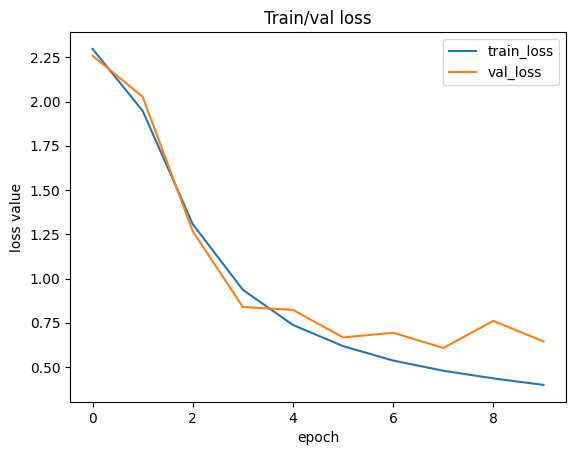

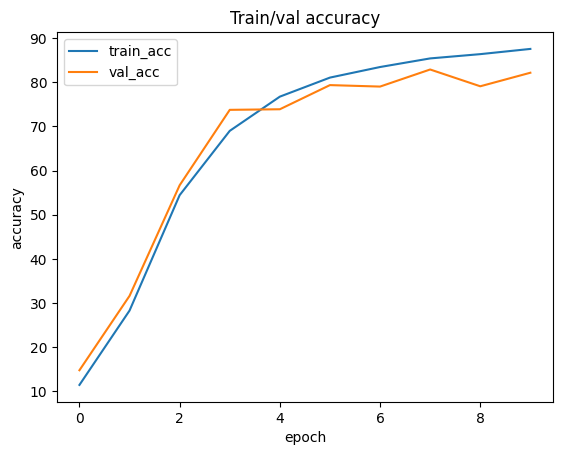

In [31]:
plot(num_epochs, train_losses, val_losses, train_accuracies, val_accuracies)

Evaluate your model.

In [33]:
model.eval()
test_loss, test_accuracy = evaluate(model, test_loader, loss_function)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.7221608513218772
Test accuracy: 79.5
